In [1]:
import keras
from keras import regularizers
from keras.preprocessing import sequence
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential, Model, model_from_json
from keras.layers import Dense, Embedding, LSTM
from keras.layers import Input, Flatten, Dropout, Activation, BatchNormalization
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D

# sklearn
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Other  
import librosa
import librosa.display
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
import seaborn as sns
import glob 
import os
from tqdm import tqdm
import pickle
import IPython.display as ipd

In [2]:
import keras
from keras import regularizers
from keras.preprocessing import sequence
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential, Model, model_from_json
from keras.layers import Dense, Embedding, LSTM
from keras.layers import Input, Flatten, Dropout, Activation, BatchNormalization
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D

# sklearn
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Other  
import librosa
import librosa.display
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
import seaborn as sns
import glob 
import os
from tqdm import tqdm
import pickle
import IPython.display as ipd

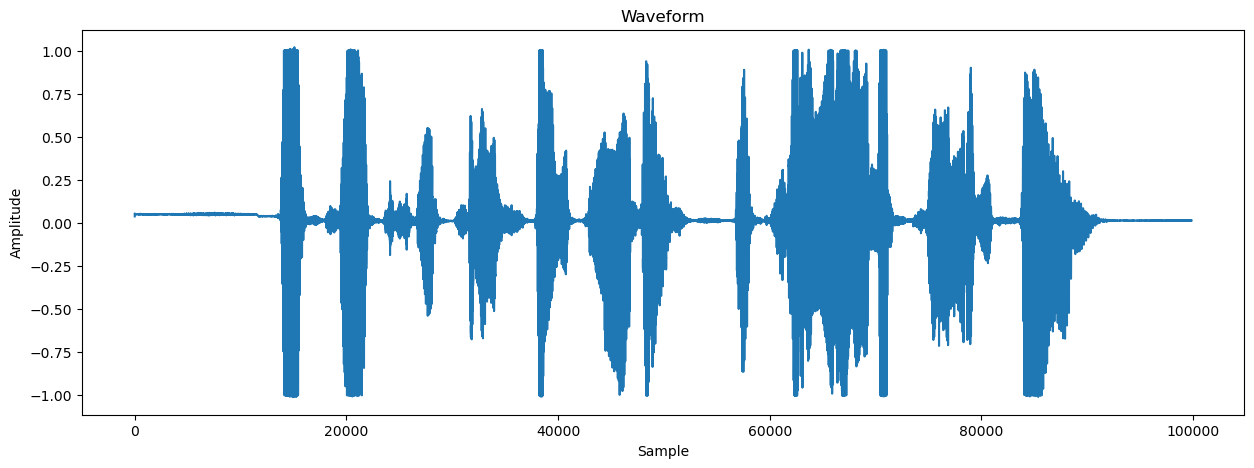

In [3]:
# Load the audio data and its sampling rate
fname = '.\surrey-audiovisual-expressed-emotion-savee/ALL/JK_f11.wav'  
data, sampling_rate = librosa.load(fname)

# Plot the waveform using Matplotlib
plt.figure(figsize=(15, 5))
plt.plot(data)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Waveform')
plt.show()
# Paly it again to refresh our memory
ipd.Audio(data, rate=sampling_rate)

# STATIC NOISE

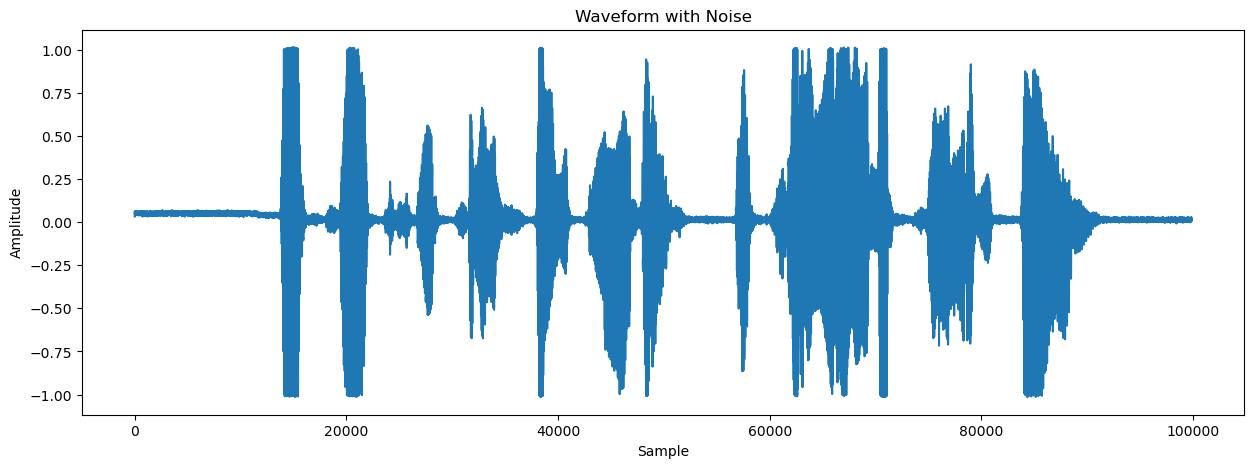

In [4]:
# Redefine noise as a function
def noise(data, noise_level=0.005):
    noise = np.random.normal(scale=noise_level, size=len(data))
    return data + noise

# Generate noisy data
x = noise(data)

# Plot the waveform of the noisy data using Matplotlib
plt.figure(figsize=(15, 5))
plt.plot(x)
plt.title('Waveform with Noise')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()

# Play the noisy audio
ipd.Audio(x, rate=sampling_rate)


# SHIFT

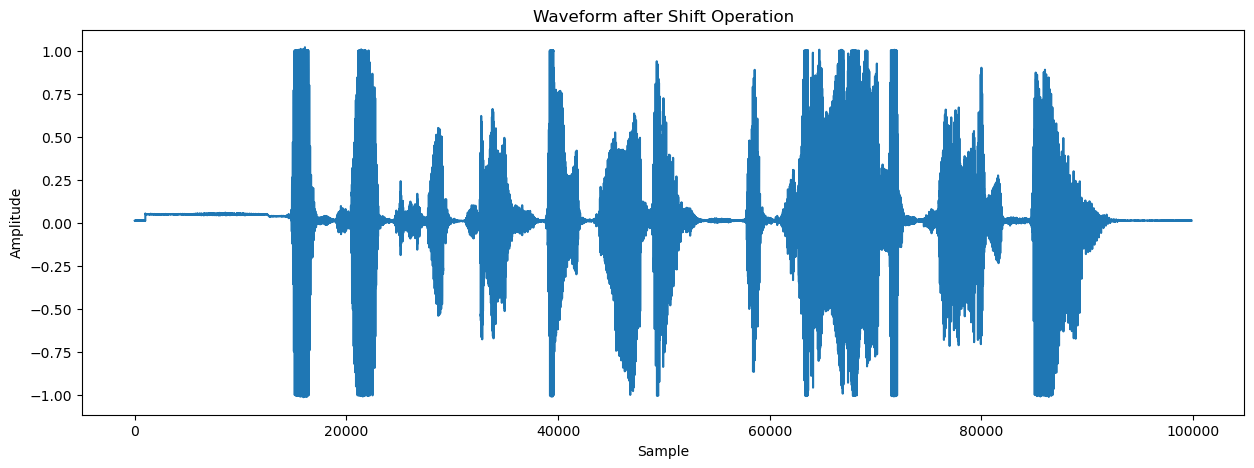

In [5]:
# Apply shift operation (assuming you have defined the shift function)

def shift(data, shift_amount=1000):
    # Shift the audio data by the specified amount
    shifted_data = np.roll(data, shift_amount)
    return shifted_data
x = shift(data)
# Plot the waveform using Matplotlib
plt.figure(figsize=(15, 5))
plt.plot(x)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Waveform after Shift Operation')
plt.show()

# Play the audio with the shift applied
ipd.Audio(x, rate=sampling_rate)

# Stretch

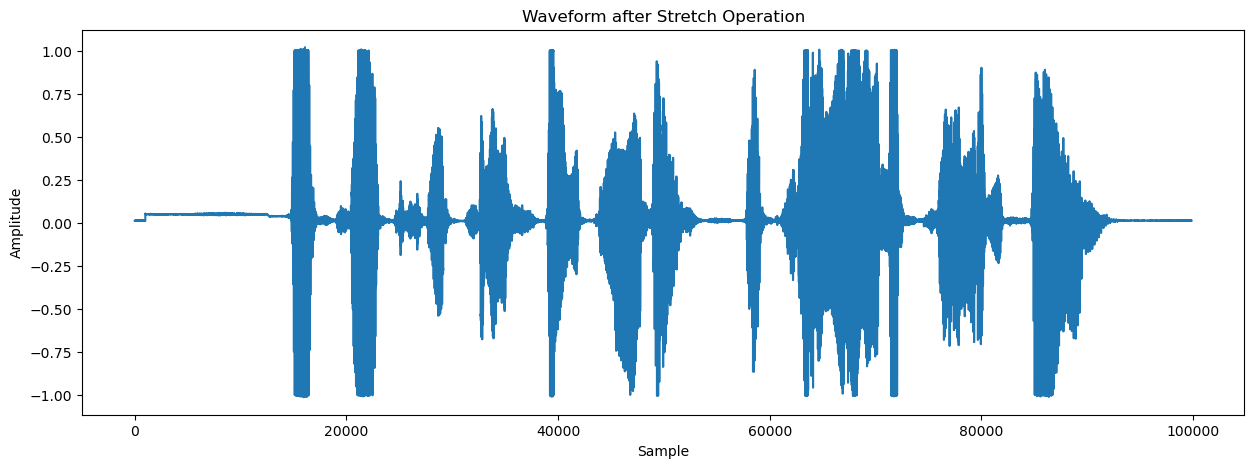

In [6]:
def stretch(data, stretch_amount=1000):
    # Stretch the audio data by the specified amount
    stretched_data = np.roll(data, stretch_amount)
    return stretched_data

# Apply the stretch operation
x = stretch(data)

# Plot the waveform using Matplotlib
plt.figure(figsize=(15, 5))
plt.plot(x)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Waveform after Stretch Operation')
plt.show()

# Play the audio with the stretch applied
ipd.Audio(x, rate=sampling_rate)

# Pitch

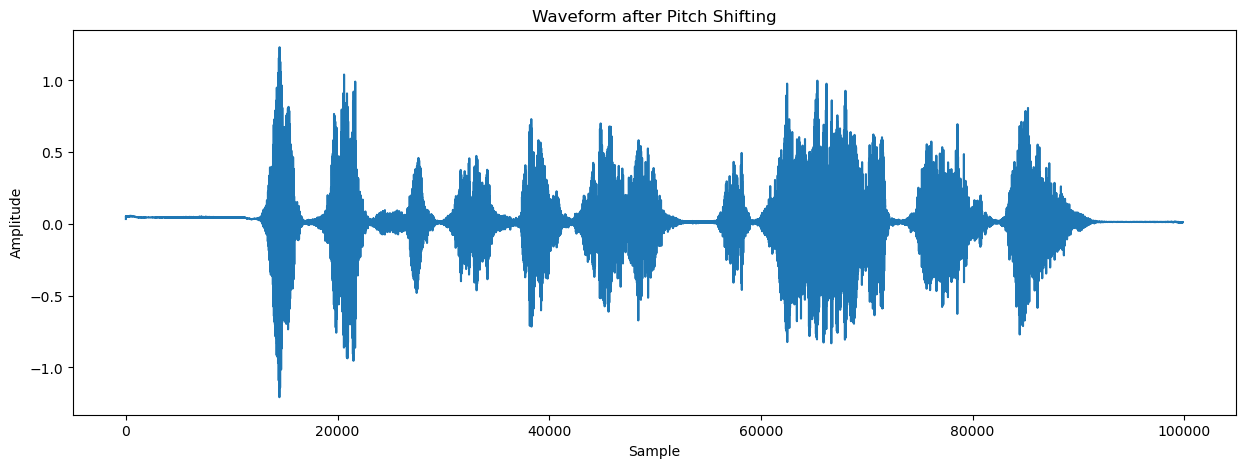

In [7]:
fname = '.\surrey-audiovisual-expressed-emotion-savee/ALL/JK_f11.wav'  
data, sampling_rate = librosa.load(fname)

# Apply pitch shifting
shifted_data = librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=4)

# Plot the waveform of the shifted audio
plt.figure(figsize=(15, 5))
plt.plot(shifted_data)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Waveform after Pitch Shifting')
plt.show()

# Play the shifted audio
ipd.Audio(shifted_data, rate=sampling_rate)

# Dynamic change

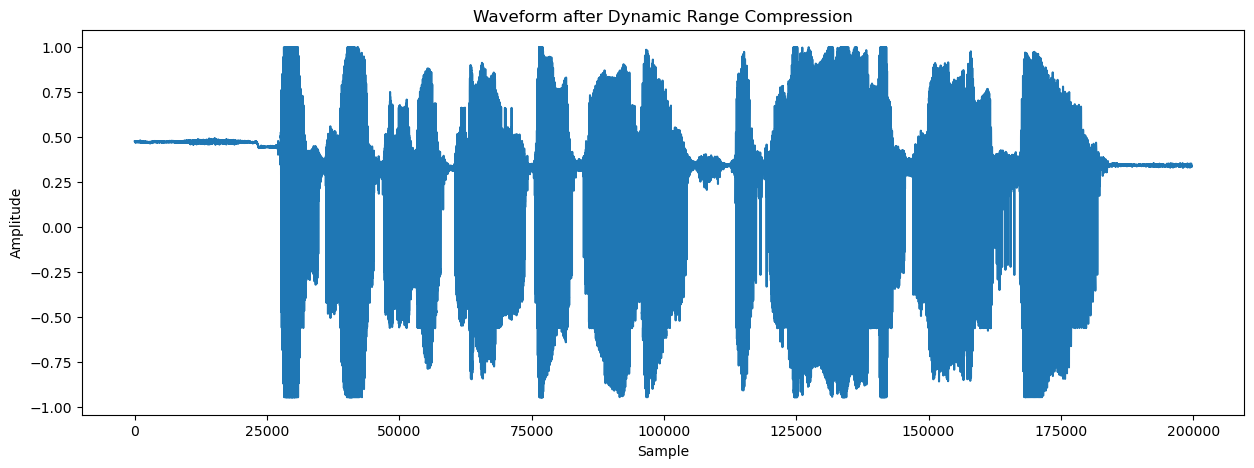

In [8]:
from scipy.io import wavfile
def dynamic_range_compression(data, threshold_db=-20, ratio=4):
    threshold = 10 ** (threshold_db / 20)
    compressed_data = np.where(np.abs(data) < threshold, data, threshold + (1 - threshold) * data)
    compressed_data = np.sign(data) * np.abs(compressed_data) ** (1 / ratio)
    return compressed_data

# Load the audio data
fname = '.\surrey-audiovisual-expressed-emotion-savee/ALL/JK_f11.wav'
sampling_rate, data = wavfile.read(fname)
data = data.astype(np.float32) / np.iinfo(np.int16).max  # Normalize to range [-1, 1]

# Apply dynamic range compression
compressed_data = dynamic_range_compression(data)

# Plot the waveform of the compressed audio
plt.figure(figsize=(15, 5))
plt.plot(compressed_data)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Waveform after Dynamic Range Compression')
plt.show()

# Play the shifted audio
ipd.Audio(shifted_data, rate=sampling_rate)

# Speed and pitch

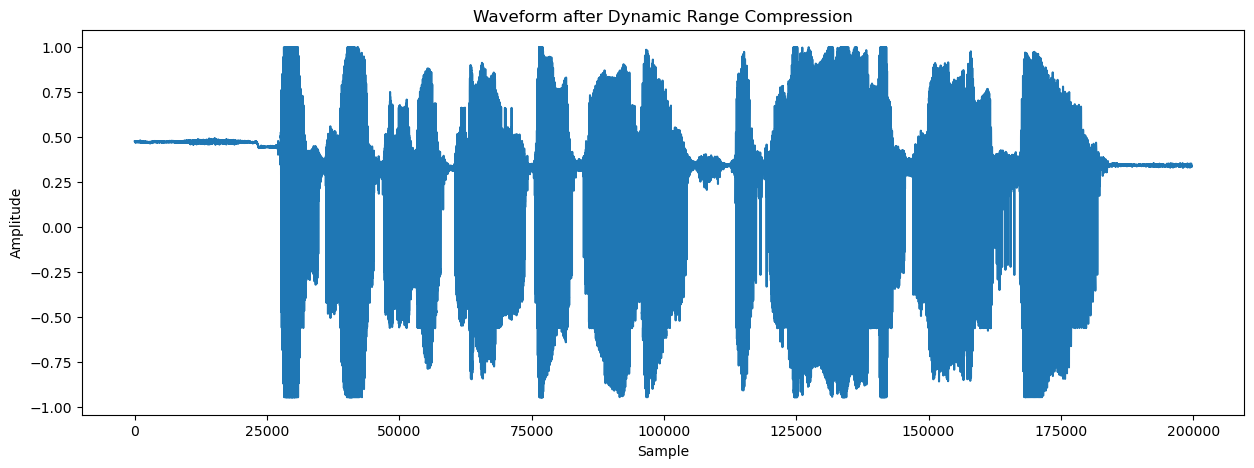

In [9]:
# Define a function for dynamic range compression
def speedNpitch(data, threshold_db=-20, ratio=4):
    threshold = 10 ** (threshold_db / 20)
    compressed_data = np.where(np.abs(data) < threshold, data, threshold + (1 - threshold) * data)
    compressed_data = np.sign(data) * np.abs(compressed_data) ** (1 / ratio)
    return compressed_data

# Load the audio data
fname = '.\surrey-audiovisual-expressed-emotion-savee/ALL/JK_f11.wav'
sampling_rate, data = wavfile.read(fname)
data = data.astype(np.float32) / np.iinfo(np.int16).max  # Normalize to range [-1, 1]

# Apply dynamic range compression
compressed_data = speedNpitch(data)

# Plot the waveform of the compressed audio
plt.figure(figsize=(15, 5))
plt.plot(compressed_data)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Waveform after Dynamic Range Compression')
plt.show()

# Play the compressed audio
ipd.Audio(compressed_data, rate=sampling_rate)

# Data preparation and processing

In [10]:
# lets pick up the meta-data
ref = pd.read_csv("Data_path.csv")
ref.head()

,labels,source,path
0,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...
1,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...
2,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...
3,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...
4,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...


In [11]:
#  we're iterating over 4 datasets  
df = pd.DataFrame(columns=['feature'])
df_noise = pd.DataFrame(columns=['feature'])
df_speedpitch = pd.DataFrame(columns=['feature'])
cnt = 0

# loop feature extraction over the entire dataset
for i in tqdm(ref.path):
    
    # first load the audio 
    X, sample_rate = librosa.load(i
                                  , res_type='kaiser_fast'
                                  ,duration=2.5
                                  ,sr=44100
                                  ,offset=0.5
                                 )

    # take mfcc and mean as the feature. Could do min and max etc as well. 
    mfccs = np.mean(librosa.feature.mfcc(y=X, 
                                        sr=np.array(sample_rate), 
                                        n_mfcc=13),
                    axis=0)
    
    df.loc[cnt] = [mfccs]   

    # random shifting (omit for now)
    # Stretch
    # pitch (omit for now)
    # dyn change
    
    # noise 
    aug = noise(X)
    aug = np.mean(librosa.feature.mfcc(y=aug, 
                                    sr=np.array(sample_rate), 
                                    n_mfcc=13),    
                  axis=0)
    df_noise.loc[cnt] = [aug]

    # speed pitch
    aug = speedNpitch(X)
    aug = np.mean(librosa.feature.mfcc(y=aug, 
                                    sr=np.array(sample_rate), 
                                    n_mfcc=13),    
                  axis=0)
    df_speedpitch.loc[cnt] = [aug]   

    cnt += 1

df.head()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12162/12162 [10:45<00:00, 18.84it/s]


,feature
0,"[-4.641421, -3.860898, -6.21919, -5.9265423, -..."
1,"[-8.690716, -12.522837, -22.928043, -23.243807..."
2,"[-8.814859, -12.819055, -24.178183, -23.84745,..."
3,"[-2.2684252, -4.317077, -12.285237, -13.083024..."
4,"[-13.485307, -16.26042, -25.884357, -27.827044..."


In [12]:
# combine 
df = pd.concat([ref,pd.DataFrame(df['feature'].values.tolist())],axis=1)
df_noise = pd.concat([ref,pd.DataFrame(df_noise['feature'].values.tolist())],axis=1)
df_speedpitch = pd.concat([ref,pd.DataFrame(df_speedpitch['feature'].values.tolist())],axis=1)
print(df.shape,df_noise.shape,df_speedpitch.shape)

(12162, 219) (12162, 219) (12162, 219)


In [13]:
df = pd.concat([df,df_noise,df_speedpitch],axis=0,sort=False)
df=df.fillna(0)
del df_noise, df_speedpitch

df.head()

,labels,source,path,0,1,2,3,4,5,6,...,206,207,208,209,210,211,212,213,214,215
0,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...,-4.641421,-3.860898,-6.219190,-5.926542,-5.850419,-4.808960,-2.513003,...,-4.088852,-5.023864,-5.254714,-5.234095,-5.310307,-5.621665,-6.072197,-6.611348,-3.999875,1.390506
1,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...,-8.690716,-12.522837,-22.928043,-23.243807,-22.926605,-23.432241,-14.830004,...,-22.627258,-22.633406,-22.511597,-24.300154,-24.496809,-22.895985,-23.511503,-24.342152,-16.465857,-8.936035
2,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...,-8.814859,-12.819055,-24.178183,-23.847450,-15.182783,-10.732485,-8.681472,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...,-2.268425,-4.317077,-12.285237,-13.083024,-12.041327,-11.819768,-9.414148,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,male_angry,SAVEE,.\surrey-audiovisual-expressed-emotion-savee/A...,-13.485307,-16.260420,-25.884357,-27.827044,-27.593534,-26.666508,-18.659023,...,-25.291666,-25.854906,-26.821354,-25.436455,-24.179941,-23.281618,-24.167494,-25.228062,-20.599659,-15.929615


In [14]:
# Split between train and test 
X_train, X_test, y_train, y_test = train_test_split(df.drop(['path','labels','source'],axis=1)
                                                    , df.labels
                                                    , test_size=0.25
                                                    , shuffle=True
                                                    , random_state=42
                                                   )

# Lets see how the data present itself before normalisation 
X_train[150:160]

,0,1,2,3,4,5,6,7,8,9,...,206,207,208,209,210,211,212,213,214,215
3857,-16.504418,-19.207904,-22.433246,-22.280596,-22.142091,-24.063365,-23.015786,-23.609402,-25.477389,-22.693164,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7298,-9.410288,-11.554614,-12.118768,-11.879835,-10.854965,-9.832913,-9.612031,-10.135081,-11.470055,-12.458235,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5874,8.776368,10.816985,10.683275,12.092161,11.284763,11.507710,11.537495,11.942571,10.995197,12.022986,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
858,-30.840989,-27.722769,-25.171294,-26.464334,-27.805762,-26.311965,-26.576622,-27.878426,-28.573738,-29.161018,...,-23.455115,-21.850416,-20.628615,-20.145097,-20.199189,-19.440135,-19.437991,-19.987791,-18.166513,-14.876563
891,-24.819444,-23.703059,-27.997384,-27.007814,-24.308994,-25.458921,-25.839658,-29.203534,-31.423232,-27.356866,...,-18.757273,-18.685462,-19.286552,-19.482866,-20.209401,-19.540808,-18.429526,-19.453033,-19.674736,-19.734761
1748,-29.360366,-28.562655,-27.288134,-26.657938,-26.775585,-28.872808,-28.169917,-27.819804,-25.477023,-26.641890,...,-27.862935,-28.856758,-28.004913,-27.261045,-28.833366,-29.018392,-27.107695,-26.749310,-26.708155,-26.761115
9995,-6.042688,-7.824288,-7.652111,-7.676592,-9.049874,-8.188551,-8.382911,-9.500729,-7.820495,-7.235802,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5771,-18.790920,-15.083409,-17.024273,-17.871832,-17.670864,-16.764324,-16.967266,-14.339257,-13.911372,-11.508421,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1029,-5.676082,-5.077873,-4.824305,-2.317750,-3.016614,-3.561986,-4.571976,-3.323014,-1.690004,-1.884858,...,1.709196,1.931288,1.911781,1.804832,2.217804,3.970019,3.019614,4.205684,3.298832,0.056593
10882,-14.959646,-14.884292,-13.614882,-12.414084,-11.447903,-11.991758,-10.696658,-11.151223,-13.877686,-17.369408,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
# Lts do data normalization 
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean)/std
X_test = (X_test - mean)/std

# Check the dataset now 
X_train[150:160]

,0,1,2,3,4,5,6,7,8,9,...,206,207,208,209,210,211,212,213,214,215
3857,-0.301853,-0.532991,-0.626307,-0.620508,-0.616624,-0.743274,-0.680968,-0.723451,-0.848556,-0.672298,...,0.362373,0.356617,0.357166,0.359401,0.352104,0.352882,0.355264,0.348999,0.339462,0.340083
7298,0.159937,-0.035407,0.028218,0.040525,0.102290,0.165078,0.175985,0.139419,0.051041,-0.013869,...,0.362373,0.356617,0.357166,0.359401,0.352104,0.352882,0.355264,0.348999,0.339462,0.340083
5874,1.343790,1.419097,1.475164,1.564094,1.512443,1.527284,1.528153,1.553229,1.493833,1.561047,...,0.362373,0.356617,0.357166,0.359401,0.352104,0.352882,0.355264,0.348999,0.339462,0.340083
858,-1.235086,-1.086591,-0.800054,-0.886411,-0.977362,-0.886806,-0.908625,-0.996831,-1.047413,-1.088385,...,-1.621230,-1.498021,-1.388807,-1.339208,-1.362181,-1.292427,-1.281062,-1.337550,-1.209605,-0.911593
891,-0.843116,-0.825246,-0.979389,-0.920952,-0.754641,-0.832354,-0.861508,-1.081688,-1.230417,-0.972321,...,-1.223933,-1.229383,-1.275217,-1.283369,-1.363048,-1.300948,-1.196167,-1.292428,-1.338212,-1.320349
1748,-1.138706,-1.141196,-0.934382,-0.898715,-0.911747,-1.050268,-1.010490,-0.993077,-0.848532,-0.926326,...,-1.994001,-2.092711,-2.013125,-1.939216,-2.094955,-2.103080,-1.926711,-1.908080,-1.937955,-1.911529
9995,0.379149,0.207122,0.311658,0.307667,0.217263,0.270040,0.254567,0.180041,0.285428,0.322099,...,0.362373,0.356617,0.357166,0.359401,0.352104,0.352882,0.355264,0.348999,0.339462,0.340083
5771,-0.450692,-0.264834,-0.283070,-0.340304,-0.331837,-0.277365,-0.294263,-0.129809,-0.105748,0.047234,...,0.362373,0.356617,0.357166,0.359401,0.352104,0.352882,0.355264,0.348999,0.339462,0.340083
1029,0.403013,0.385682,0.491102,0.648255,0.601541,0.565361,0.498214,0.575650,0.679148,0.666333,...,0.506921,0.520542,0.518976,0.511582,0.540327,0.688884,0.609461,0.703871,0.620755,0.344845
10882,-0.201297,-0.251888,-0.066721,0.006570,0.064524,0.027276,0.106640,0.074347,-0.103585,-0.329812,...,0.362373,0.356617,0.357166,0.359401,0.352104,0.352882,0.355264,0.348999,0.339462,0.340083


In [16]:
# Lets few preparation steps to get it into the correct format for Keras 
from tensorflow.keras.utils import to_categorical
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

# one hot encode the target 
lb = LabelEncoder()
y_train = to_categorical(lb.fit_transform(y_train))
y_test = to_categorical(lb.fit_transform(y_test))

print(X_train.shape)
print(lb.classes_)

# Pickel the lb object for future use 
filename = 'labels'
outfile = open(filename,'wb')
pickle.dump(lb,outfile)
outfile.close()

(27364, 216)
['female_angry' 'female_disgust' 'female_fear' 'female_happy'
 'female_neutral' 'female_sad' 'female_surprise' 'male_angry'
 'male_disgust' 'male_fear' 'male_happy' 'male_neutral' 'male_sad'
 'male_surprise']


In [17]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)
X_train.shape

(27364, 216, 1)

# Modelling

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
import tensorflow.keras as keras
from tensorflow.keras.optimizers import RMSprop

In [19]:
#New model
model = Sequential()
model.add(Conv1D(256, 8, padding='same',input_shape=(X_train.shape[1],1)))  # X_train.shape[1] = No. of Columns
model.add(Activation('relu'))
model.add(Conv1D(256, 8, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))
model.add(MaxPooling1D(pool_size=(8)))
model.add(Conv1D(128, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(128, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(128, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(128, 8, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))
model.add(MaxPooling1D(pool_size=(8)))
model.add(Conv1D(64, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(64, 8, padding='same'))
model.add(Activation('relu'))
model.add(Flatten())
model.add(Dense(14)) # Target class number
model.add(Activation('softmax'))
# opt = keras.optimizers.SGD(lr=0.0001, momentum=0.0, decay=0.0, nesterov=False)
# opt = keras.optimizers.Adam(lr=0.0001)
opt = keras.optimizers.RMSprop(learning_rate=0.00001)
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 216, 256)          2304      
                                                                 
 activation (Activation)     (None, 216, 256)          0         
                                                                 
 conv1d_1 (Conv1D)           (None, 216, 256)          524544    
                                                                 
 batch_normalization (Batch  (None, 216, 256)          1024      
 Normalization)                                                  
                                                                 
 activation_1 (Activation)   (None, 216, 256)          0         
                                                                 
 dropout (Dropout)           (None, 216, 256)          0         
                                                      

In [20]:
model.compile(loss='categorical_crossentropy', optimizer=opt,metrics=['accuracy'])
model_history=model.fit(X_train, y_train, batch_size=16, epochs=150, validation_data=(X_test, y_test),verbose=2)

Epoch 1/150


1711/1711 - 163s - loss: 2.4236 - accuracy: 0.1738 - val_loss: 2.3629 - val_accuracy: 0.2061 - 163s/epoch - 95ms/step
Epoch 2/150
1711/1711 - 165s - loss: 2.2417 - accuracy: 0.2215 - val_loss: 2.2727 - val_accuracy: 0.2307 - 165s/epoch - 96ms/step
Epoch 3/150
1711/1711 - 169s - loss: 2.1394 - accuracy: 0.2570 - val_loss: 2.1935 - val_accuracy: 0.2707 - 169s/epoch - 99ms/step
Epoch 4/150
1711/1711 - 165s - loss: 2.0642 - accuracy: 0.2868 - val_loss: 2.1252 - val_accuracy: 0.2901 - 165s/epoch - 97ms/step
Epoch 5/150
1711/1711 - 165s - loss: 2.0054 - accuracy: 0.3078 - val_loss: 2.0667 - val_accuracy: 0.3065 - 165s/epoch - 96ms/step
Epoch 6/150
1711/1711 - 168s - loss: 1.9566 - accuracy: 0.3195 - val_loss: 2.0652 - val_accuracy: 0.2980 - 168s/epoch - 98ms/step
Epoch 7/150
1711/1711 - 165s - loss: 1.9194 - accuracy: 0.3318 - val_loss: 2.0000 - val_accuracy: 0.3228 - 165s/epoch - 97ms/step
Epoch 8/150
1711/1711 - 165s - loss: 1.8895 - accuracy: 0.3405 - val_loss: 2.0081 - val_

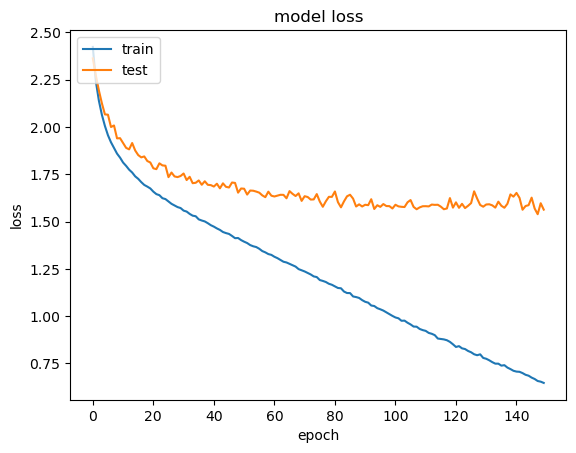

In [21]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Model serialisation

In [22]:
# Save model and weights
model_name = 'Emotion_Model_aug.h5'
save_dir = os.path.join(os.getcwd(), 'saved_models')

if not os.path.isdir(save_dir):
    os.makedirs(save_dir)
model_path = os.path.join(save_dir, model_name)
model.save(model_path)
print('Save model and weights at %s ' % model_path)

# Save the model to disk
model_json = model.to_json()
with open("model_json_aug.json", "w") as json_file:
    json_file.write(model_json)

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Save model and weights at C:\Users\Lenovo\saved_models\Emotion_Model_aug.h5 


# Model validation

In [23]:
# loading json and model architecture 
json_file = open('model_json_aug.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)

# load weights into new model
loaded_model.load_weights("saved_models/Emotion_Model_aug.h5")
print("Loaded model from disk")
 
# Keras optimiser
opt = keras.optimizers.RMSprop(learning_rate=0.00001)
loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
score = loaded_model.evaluate(X_test, y_test, verbose=0)
print("%s: %.2f%%" % (loaded_model.metrics_names[1], score[1]*100))

Loaded model from disk
accuracy: 49.32%


In [24]:
preds = loaded_model.predict(X_test, 
                         batch_size=16, 
                         verbose=1)

preds=preds.argmax(axis=1)
preds

571/571 [==============================] - 18s 29ms/step


array([ 2, 12, 12, ..., 12,  4,  2], dtype=int64)

In [25]:
# predictions 
preds = preds.astype(int).flatten()
preds = (lb.inverse_transform((preds)))
preds = pd.DataFrame({'predictedvalues': preds})

# Actual labels
actual=y_test.argmax(axis=1)
actual = actual.astype(int).flatten()
actual = (lb.inverse_transform((actual)))
actual = pd.DataFrame({'actualvalues': actual})

# Lets combined both of them into a single dataframe
finaldf = actual.join(preds)
finaldf[170:180]

,actualvalues,predictedvalues
170,female_surprise,female_neutral
171,female_fear,female_fear
172,female_neutral,female_neutral
173,female_neutral,female_neutral
174,male_surprise,male_surprise
175,male_disgust,male_sad
176,female_fear,female_fear
177,female_disgust,female_disgust
178,male_neutral,male_neutral
179,male_fear,female_neutral


In [26]:
# Write out the predictions to disk
finaldf.to_csv('Predictions.csv', index=False)
finaldf.groupby('predictedvalues').count()

,actualvalues
predictedvalues,
female_angry,1049
female_disgust,832
female_fear,729
female_happy,637
female_neutral,998
female_sad,935
female_surprise,362
male_angry,490
male_disgust,457


# Emotion by gender accuracy

In [28]:
# the confusion matrix heat map plot
def print_confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=14):
   
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names, 
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
        
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Gender recode function
def gender(row):
    if row == 'female_disgust' or 'female_fear' or 'female_happy' or 'female_sad' or 'female_surprise' or 'female_neutral':
        return 'female'
    elif row == 'male_angry' or 'male_fear' or 'male_happy' or 'male_sad' or 'male_surprise' or 'male_neutral' or 'male_disgust':
        return 'male'

0.49320324490243367


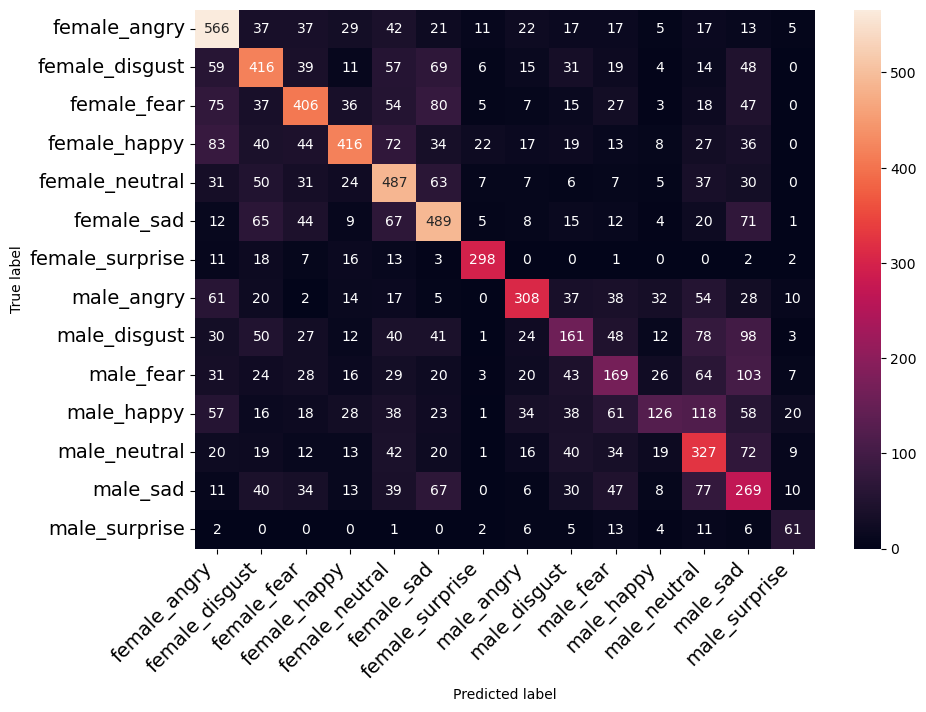

In [29]:
# Get the predictions file 
finaldf = pd.read_csv("Predictions.csv")
classes = finaldf.actualvalues.unique()
classes.sort()    

# Confusion matrix 
c = confusion_matrix(finaldf.actualvalues, finaldf.predictedvalues)
print(accuracy_score(finaldf.actualvalues, finaldf.predictedvalues))
print_confusion_matrix(c, class_names = classes)

In [30]:
# Classification report 
classes = finaldf.actualvalues.unique()
classes.sort()    
print(classification_report(finaldf.actualvalues, finaldf.predictedvalues, target_names=classes))

                 precision    recall  f1-score   support

   female_angry       0.54      0.67      0.60       839
 female_disgust       0.50      0.53      0.51       788
    female_fear       0.56      0.50      0.53       810
   female_happy       0.65      0.50      0.57       831
 female_neutral       0.49      0.62      0.55       785
     female_sad       0.52      0.59      0.56       822
female_surprise       0.82      0.80      0.81       371
     male_angry       0.63      0.49      0.55       626
   male_disgust       0.35      0.26      0.30       625
      male_fear       0.33      0.29      0.31       583
     male_happy       0.49      0.20      0.28       636
   male_neutral       0.38      0.51      0.43       644
       male_sad       0.31      0.41      0.35       651
  male_surprise       0.48      0.55      0.51       111

       accuracy                           0.49      9122
      macro avg       0.50      0.50      0.49      9122
   weighted avg       0.50   

# Gender accuracy result

0.8158298618723964


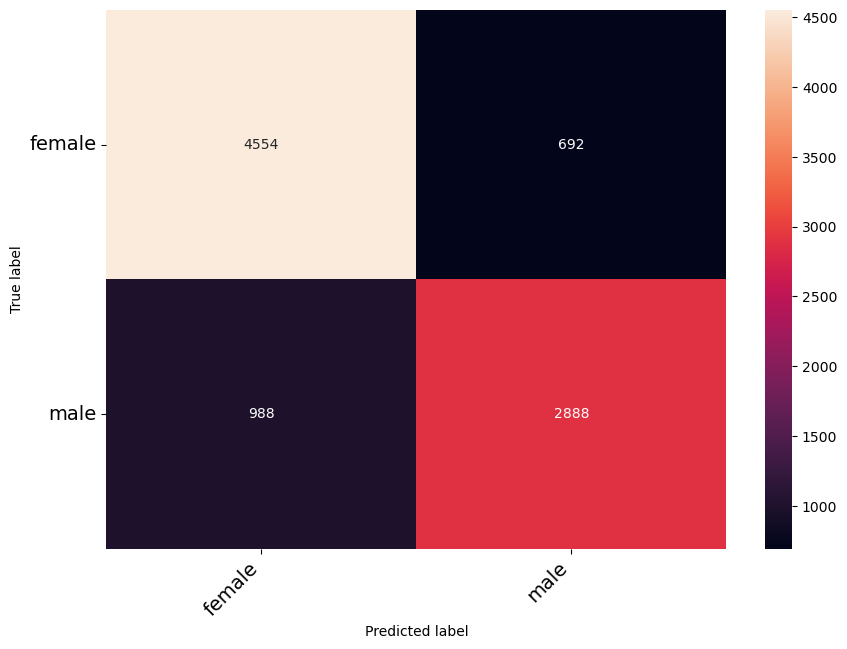

In [31]:
modidf = finaldf
modidf['actualvalues'] = finaldf.actualvalues.replace({'female_angry':'female'
                                       , 'female_disgust':'female'
                                       , 'female_fear':'female'
                                       , 'female_happy':'female'
                                       , 'female_sad':'female'
                                       , 'female_surprise':'female'
                                       , 'female_neutral':'female'
                                       , 'male_angry':'male'
                                       , 'male_fear':'male'
                                       , 'male_happy':'male'
                                       , 'male_sad':'male'
                                       , 'male_surprise':'male'
                                       , 'male_neutral':'male'
                                       , 'male_disgust':'male'
                                      })

modidf['predictedvalues'] = finaldf.predictedvalues.replace({'female_angry':'female'
                                       , 'female_disgust':'female'
                                       , 'female_fear':'female'
                                       , 'female_happy':'female'
                                       , 'female_sad':'female'
                                       , 'female_surprise':'female'
                                       , 'female_neutral':'female'
                                       , 'male_angry':'male'
                                       , 'male_fear':'male'
                                       , 'male_happy':'male'
                                       , 'male_sad':'male'
                                       , 'male_surprise':'male'
                                       , 'male_neutral':'male'
                                       , 'male_disgust':'male'
                                      })

classes = modidf.actualvalues.unique()  
classes.sort() 

# Confusion matrix 
c = confusion_matrix(modidf.actualvalues, modidf.predictedvalues)
print(accuracy_score(modidf.actualvalues, modidf.predictedvalues))
print_confusion_matrix(c, class_names = classes)

In [32]:
# Classification report 
classes = modidf.actualvalues.unique()
classes.sort()    
print(classification_report(modidf.actualvalues, modidf.predictedvalues, target_names=classes))

              precision    recall  f1-score   support

      female       0.82      0.87      0.84      5246
        male       0.81      0.75      0.77      3876

    accuracy                           0.82      9122
   macro avg       0.81      0.81      0.81      9122
weighted avg       0.82      0.82      0.81      9122



0.545384784038588


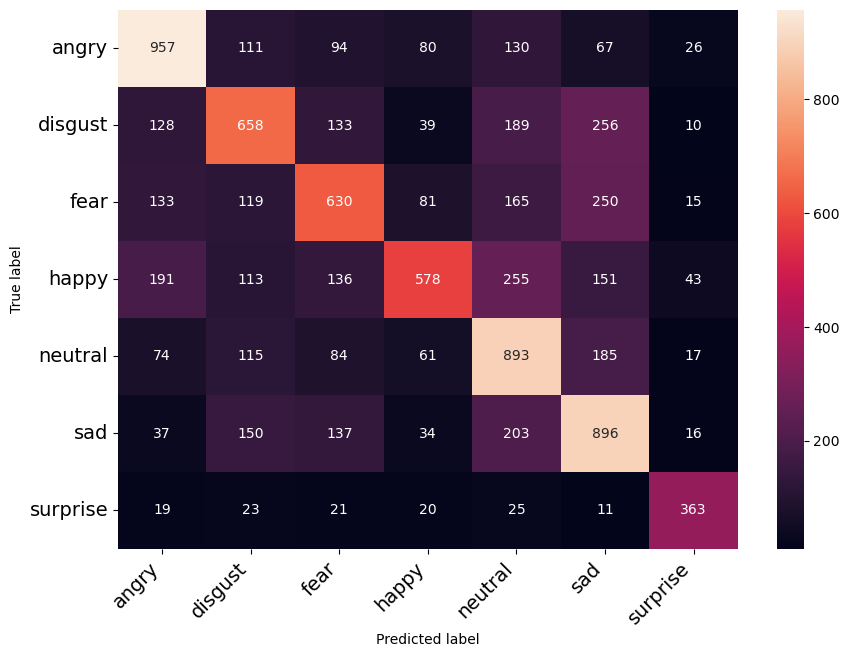

In [33]:
modidf = pd.read_csv("Predictions.csv")
modidf['actualvalues'] = modidf.actualvalues.replace({'female_angry':'angry'
                                       , 'female_disgust':'disgust'
                                       , 'female_fear':'fear'
                                       , 'female_happy':'happy'
                                       , 'female_sad':'sad'
                                       , 'female_surprise':'surprise'
                                       , 'female_neutral':'neutral'
                                       , 'male_angry':'angry'
                                       , 'male_fear':'fear'
                                       , 'male_happy':'happy'
                                       , 'male_sad':'sad'
                                       , 'male_surprise':'surprise'
                                       , 'male_neutral':'neutral'
                                       , 'male_disgust':'disgust'
                                      })

modidf['predictedvalues'] = modidf.predictedvalues.replace({'female_angry':'angry'
                                       , 'female_disgust':'disgust'
                                       , 'female_fear':'fear'
                                       , 'female_happy':'happy'
                                       , 'female_sad':'sad'
                                       , 'female_surprise':'surprise'
                                       , 'female_neutral':'neutral'
                                       , 'male_angry':'angry'
                                       , 'male_fear':'fear'
                                       , 'male_happy':'happy'
                                       , 'male_sad':'sad'
                                       , 'male_surprise':'surprise'
                                       , 'male_neutral':'neutral'
                                       , 'male_disgust':'disgust'
                                      })

classes = modidf.actualvalues.unique() 
classes.sort() 

# Confusion matrix 
c = confusion_matrix(modidf.actualvalues, modidf.predictedvalues)
print(accuracy_score(modidf.actualvalues, modidf.predictedvalues))
print_confusion_matrix(c, class_names = classes)

In [34]:
# Classification report 
classes = modidf.actualvalues.unique()
classes.sort()    
print(classification_report(modidf.actualvalues, modidf.predictedvalues, target_names=classes))

              precision    recall  f1-score   support

       angry       0.62      0.65      0.64      1465
     disgust       0.51      0.47      0.49      1413
        fear       0.51      0.45      0.48      1393
       happy       0.65      0.39      0.49      1467
     neutral       0.48      0.62      0.54      1429
         sad       0.49      0.61      0.54      1473
    surprise       0.74      0.75      0.75       482

    accuracy                           0.55      9122
   macro avg       0.57      0.56      0.56      9122
weighted avg       0.55      0.55      0.54      9122

